In [1]:
from pathlib import Path

# Project paths
ROOT = Path().resolve().parent
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"

# Verify the path is correct
print(ROOT)
print(DATA_RAW)
print(list(DATA_RAW.iterdir()))

/home/roshni/Storage/Programming/RU-Lifespan/backend
/home/roshni/Storage/Programming/RU-Lifespan/backend/data/raw
[PosixPath('/home/roshni/Storage/Programming/RU-Lifespan/backend/data/raw/ai4i2020.csv')]


In [2]:
import pandas as pd
df = pd.read_csv(DATA_RAW / "ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (10000, 14)

Column types:
 UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Missing values:
 UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [4]:
print("Failure distribution:")
print(df['Machine failure'].value_counts())
print("\nFailure rate:")
print(df['Machine failure'].value_counts(normalize=True).round(3) * 100, "%")

Failure distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64 %


In [5]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

print("Failure mode distribution:")
for mode in failure_modes:
    count = df[mode].sum()
    pct = (count / len(df) * 100).round(2)
    print(f"  {mode}: {count} cases ({pct}%)")

Failure mode distribution:
  TWF: 46 cases (0.46%)
  HDF: 115 cases (1.15%)
  PWF: 95 cases (0.95%)
  OSF: 98 cases (0.98%)
  RNF: 19 cases (0.19%)


__Distributions of Data__

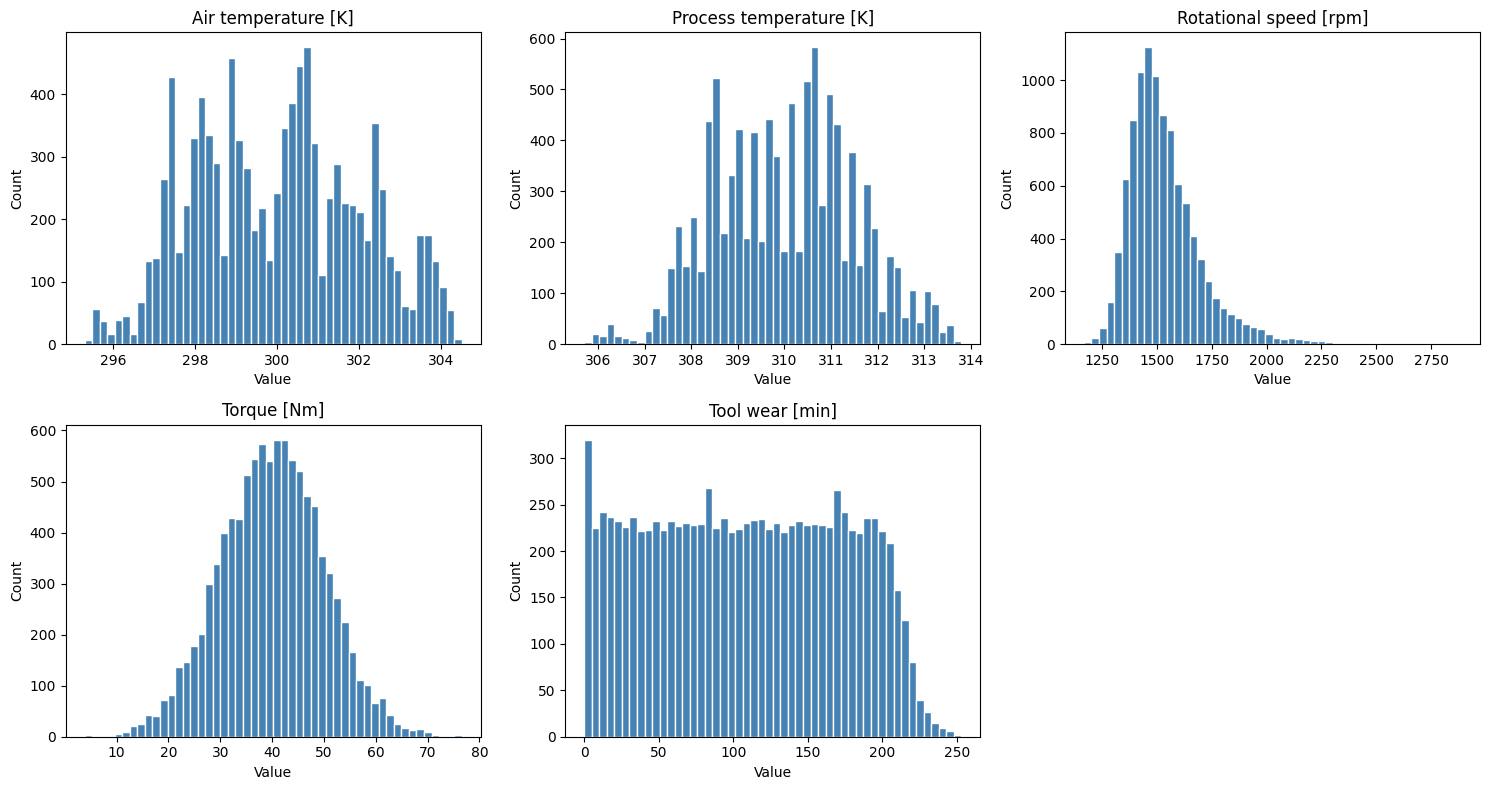

In [6]:
import matplotlib.pyplot as plt
sensors = ['Air temperature [K]', 'Process temperature [K]', 
           'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, sensor in enumerate(sensors):
    axes[i].hist(df[sensor], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

__Histograms of Failures vs Non failures across data__

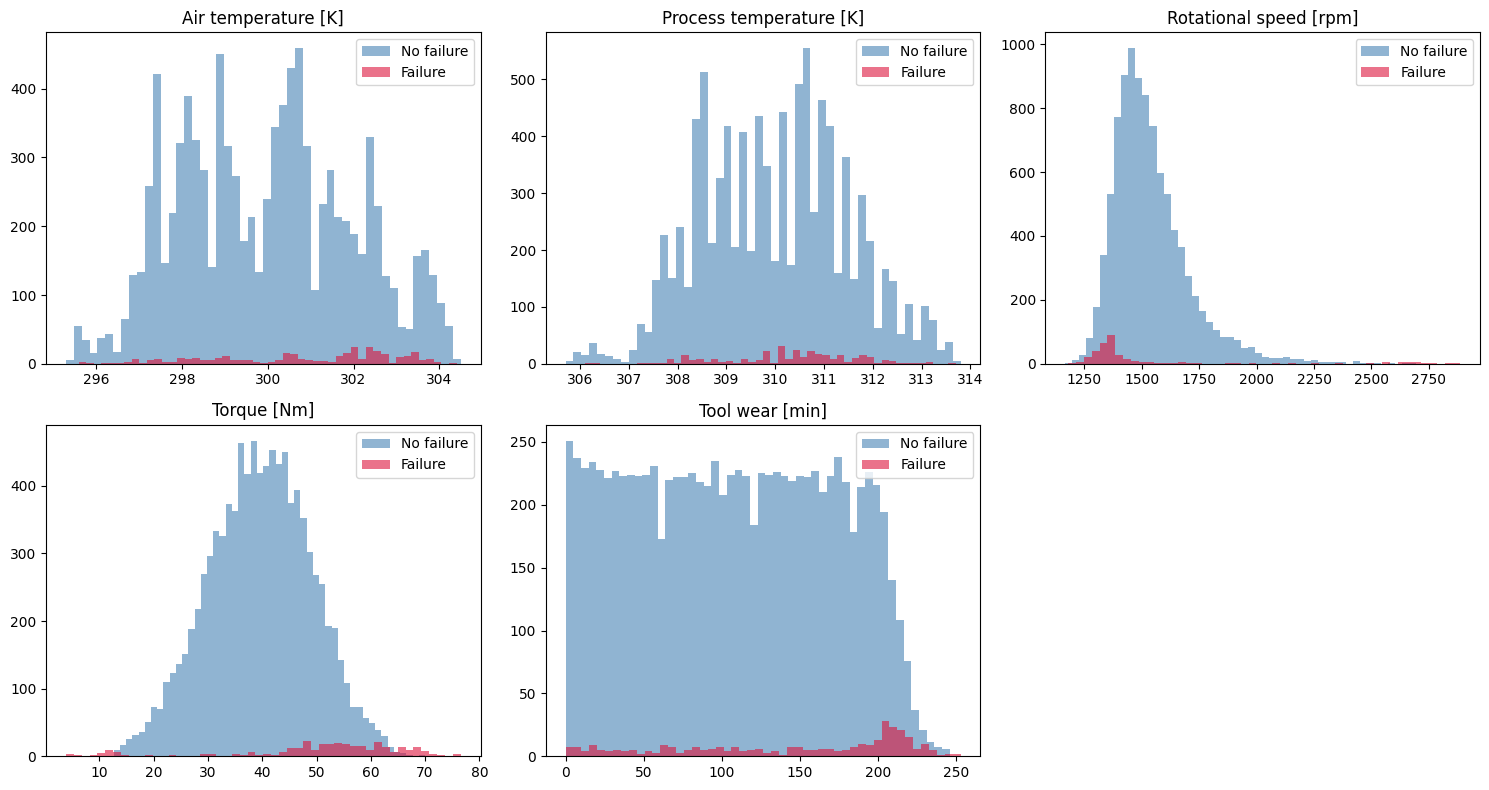

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, sensor in enumerate(sensors):
    axes[i].hist(df[df['Machine failure'] == 0][sensor], 
                 bins=50, alpha=0.6, color='steelblue', label='No failure')
    axes[i].hist(df[df['Machine failure'] == 1][sensor], 
                 bins=50, alpha=0.6, color='crimson', label='Failure')
    axes[i].set_title(sensor)
    axes[i].legend()

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

__Correlation Matrix__

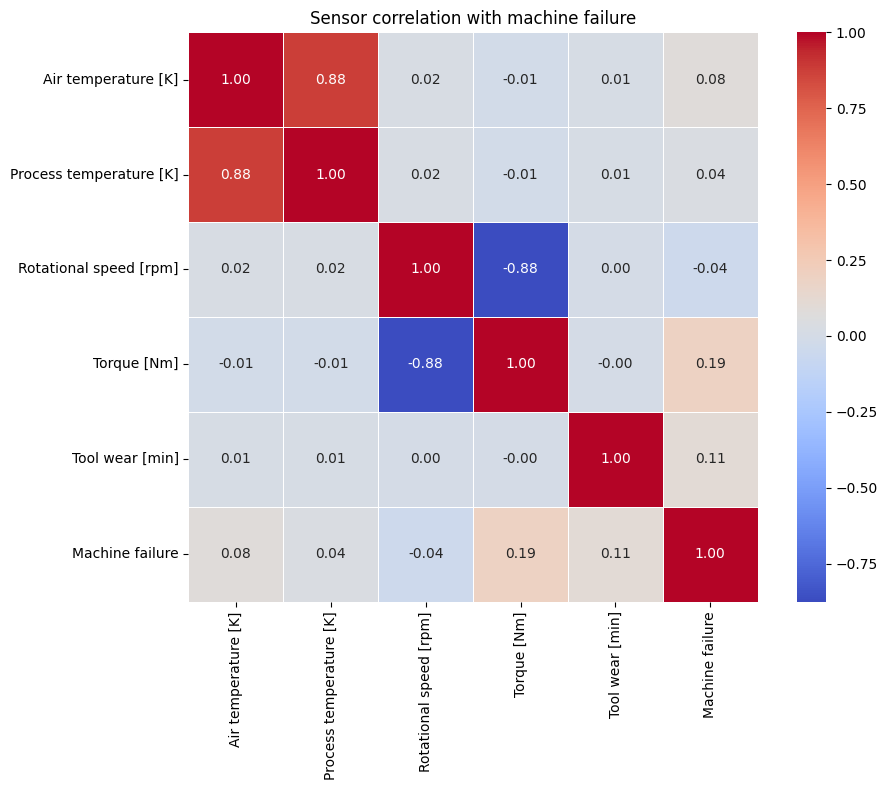

In [8]:
import seaborn as sns
corr_cols = sensors + ['Machine failure']
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Sensor correlation with machine failure')
plt.tight_layout()
plt.show()

__Failure Rate across Product Type__

In [9]:
print("Failure rate by product type:")
print(df.groupby('Type')['Machine failure']
      .agg(['sum', 'count', 'mean'])
      .rename(columns={'sum': 'failures', 'count': 'total', 'mean': 'failure_rate'})
      .round(3))

Failure rate by product type:
      failures  total  failure_rate
Type                               
H           21   1003         0.021
L          235   6000         0.039
M           83   2997         0.028
